In [1]:
import pandas as pd
import numpy as np
import re
import requests
import seaborn as sns
import matplotlib.pyplot as plt

from bootcampviztools import plot_grouped_histograms

from bs4 import BeautifulSoup

from catboost import CatBoostRegressor

from lightgbm import LGBMRegressor

from optuna import create_study

from sklearn.compose import ColumnTransformer, make_column_selector, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import  KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeRegressor

from time import time

from toolbox_ML_v2 import describe_df, tipifica_variables

from utils import extraer_informacion, obtener_urls, aplanar_campos_anidados, crear_features_poi, limpiar_y_crear_features

from xgboost import XGBRegressor

import bootcampviztools as bt

pd.set_option('display.max_columns', 500)

url = 'https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC' # Mapa de la Comunidad de Madrid y alrededores
df = pd.read_csv('../data/pisos_madrid.csv', sep ='|')

c:\Users\phbas\Documents\Bootcamp_Data_Science\ML_Prediccion_Precio_Vivienda_Madrid\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Extracción de datos

In [2]:
response = requests.get(url, timeout=10)
soup = BeautifulSoup(response.text, 'html.parser')
ultima = soup.find('a', string='>>')
max_pages = int(re.findall(r'pag-(\d+)', str(ultima))[0])

url_splited = url.split('pag-1')
data = []
for i in range(1, max_pages+1):
    subdata = obtener_urls(f'pag-{i}'.join(url_splited), df)
    data.extend(subdata)

    if len(subdata) < 15:
        break

df = pd.concat([pd.DataFrame(data), df]).reset_index(drop=True)
df.to_csv('../data/pisos_madrid.csv', sep='|', index=False)

Buscando pisos en la página https://www.tecnocasa.es/venta/piso/mapa.html/pag-1?view=41.18051487737182,-2.109104143945018,39.64144152264612,-5.319858538475728&zoom=9&sort=Aggiornamento|DESC ...
Ya lo tengo: https://www.tecnocasa.es/venta/piso/madrid/madrid/650140.html


# Train test split

In [ ]:
X = df.drop(columns='precio')
y = df['precio'].astype(str).str.extract(r'([\d\.]+) €').replace(r'\.', '', regex=True).astype(int)
y.describe()

,0
count,1.208000e+03
mean,2.976244e+05
std,1.824962e+05
min,4.490000e+04
25%,1.920000e+05
50%,2.500000e+05
75%,3.350000e+05
max,1.950000e+06


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state = 42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(966, 11)
(242, 11)
(966, 1)
(242, 1)


# Pretratamiento de datos

In [5]:
DROP_COLS = ['url', 'features', 'descripcion', 'precio', 'media', 'points_of_interest',
             'energy_data', 'transporte_publico', 'escuelas', 'farmacias', 'hospitales',
             'supermercados', 'tiendas', 'bares', 'restaurantes']
drop_step = FunctionTransformer(
    lambda df: df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
)

In [6]:
pipe_features = Pipeline([
    ('aplanar_campos', FunctionTransformer(aplanar_campos_anidados)),        
    ('poi_features', FunctionTransformer(crear_features_poi)),          
    ('final_clean', FunctionTransformer(limpiar_y_crear_features)),
    ('drop',drop_step)
])

X_train_limpio = pipe_features.fit_transform(X_train)

# MiniEDA

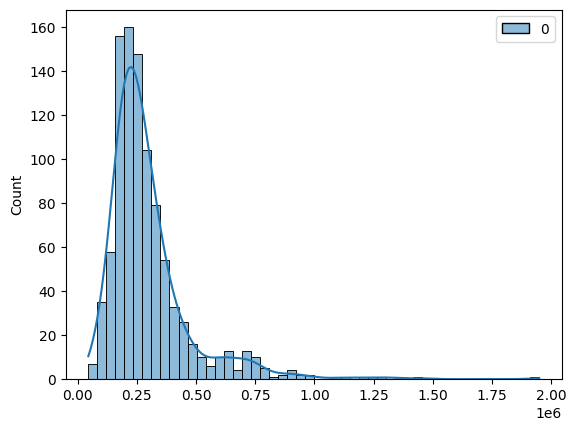

In [7]:
sns.histplot(y_train, color='Blue', kde = True,bins=50)
plt.show()

Distribución del precio con cola derecha pronunciada: la mayoría de viviendas se concentra entre ~200k y ~350k, pero hay un grupo pequeño de anuncios muy caros (outliers) que estiran la cola hasta ~2M.

In [8]:
describe_df(X_train_limpio)

Clasificación sugerida para 966 filas, con un umbral para categórica nominal de 10 sobre la cardinalidad y un umbral para númerica continua de 10.0 % sobre la cardinalidad relativa.


,dormitorios,superficie_m2,baños,latitud,longitud,planta,aire_acondicionado,ascensor,calefaccion,ano_construccion,planos,realista,fotografias,eficiencia_energetica,emisiones_energeticas,tp_cnt,tp_min_dist_m,esc_cnt,esc_min_dist_m,fca_cnt,fca_min_dist_m,hosp_cnt,hosp_min_dist_m,super_cnt,super_min_dist_m,tda_cnt,tda_min_dist_m,bar_cnt,bar_min_dist_m,resto_cnt,resto_min_dist_m,calefaccion_gas,calefaccion_electrica,categoria_ord,clase_energetica_ord,tiene_certificado
Columnas,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Tipo_Dato,float64,float64,float64,float64,float64,float64,str,int64,str,int64,int64,bool,int64,float64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,float64,int64,int64,int64,float64,bool
Nulos,95,0,79,0,0,368,0,0,0,0,0,0,0,306,307,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,306,0
Nulos_%,9.8,0.0,8.2,0.0,0.0,38.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.7,31.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.7,0.0
Cardinalidad,6,158,5,818,940,13,3,2,3,93,2,2,45,431,292,6,77,6,77,6,90,6,112,6,100,6,114,6,115,6,102,2,2,3,7,2
Cardinalidad_%,0.62,16.36,0.52,84.68,97.31,1.35,0.31,0.21,0.31,9.63,0.21,0.21,4.66,44.62,30.23,0.62,7.97,0.62,7.97,0.62,9.32,0.62,11.59,0.62,10.35,0.62,11.8,0.62,11.9,0.62,10.56,0.21,0.21,0.31,0.72,0.21
Clasificacion_sugerida,Categorica,Numerica_Continua,Categorica,Numerica_Continua,Numerica_Continua,Numerica_Discreta,Categorica,Categorica_Binaria,Categorica,Numerica_Discreta,Categorica_Binaria,Categorica_Binaria,Numerica_Discreta,Numerica_Continua,Numerica_Continua,Categorica,Numerica_Discreta,Categorica,Numerica_Discreta,Categorica,Numerica_Discreta,Categorica,Numerica_Continua,Categorica,Numerica_Continua,Categorica,Numerica_Continua,Categorica,Numerica_Continua,Categorica,Numerica_Continua,Categorica_Binaria,Categorica_Binaria,Categorica,Categorica,Categorica_Binaria


In [9]:
binaria = tipifica_variables(X_train_limpio)['Categorica_Binaria']
categorica = tipifica_variables(X_train_limpio)['Categorica']
num_discreta = tipifica_variables(X_train_limpio)['Numerica_Discreta']
num_continua = tipifica_variables(X_train_limpio)['Numerica_Continua']
numericas = num_discreta + num_continua

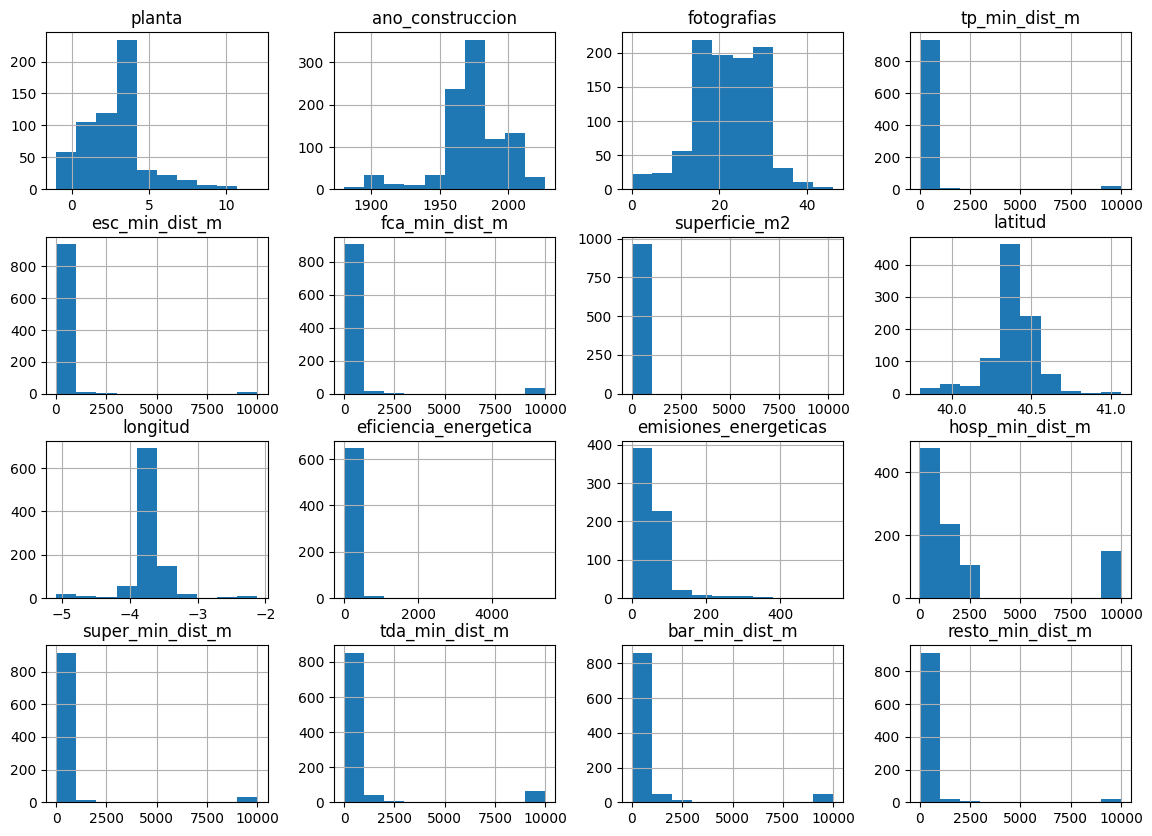

In [10]:
X_train_limpio[numericas].hist(figsize=(14, 10));

### Comparación de modelos

In [11]:
num_sel = make_column_selector(dtype_include = np.number)
cat_sel = make_column_selector(dtype_include = object)

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median'))
            ]), num_sel),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_sel),
    ],
    remainder='drop',
).set_output(transform='pandas')

preprocess_scale = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), num_sel),
        
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_sel),

    ],
    remainder='drop'
).set_output(transform='pandas')

preprocess.fit_transform(X_train_limpio)

,num__dormitorios,num__superficie_m2,num__baños,num__latitud,num__longitud,num__planta,num__ascensor,num__ano_construccion,num__planos,num__fotografias,num__eficiencia_energetica,num__emisiones_energeticas,num__tp_cnt,num__tp_min_dist_m,num__esc_cnt,num__esc_min_dist_m,num__fca_cnt,num__fca_min_dist_m,num__hosp_cnt,num__hosp_min_dist_m,num__super_cnt,num__super_min_dist_m,num__tda_cnt,num__tda_min_dist_m,num__bar_cnt,num__bar_min_dist_m,num__resto_cnt,num__resto_min_dist_m,num__calefaccion_gas,num__calefaccion_electrica,num__categoria_ord,num__clase_energetica_ord,cat__aire_acondicionado_Centralizada,cat__aire_acondicionado_Independiente,cat__aire_acondicionado_NO,cat__calefaccion_Independiente,cat__calefaccion_NO,cat__calefaccion_centralizada
788,3.0,104.0,1.0,40.377002,-3.753832,0.0,0.0,1972.0,0.0,37.0,223.1,50.0,5.0,170.0,5.0,140.0,5.0,120.0,5.0,670.0,5.0,440.0,5.0,90.0,5.0,240.0,5.0,80.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,1.0,0.0
665,2.0,42.0,1.0,40.446802,-3.703233,2.0,0.0,1925.0,0.0,22.0,162.0,34.0,5.0,60.0,5.0,150.0,5.0,50.0,5.0,380.0,5.0,110.0,5.0,40.0,5.0,100.0,5.0,50.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,1.0,0.0
296,4.0,75.0,1.0,40.489802,-3.372123,3.0,0.0,1965.0,0.0,22.0,999.9,99.9,4.0,100.0,5.0,60.0,5.0,430.0,5.0,940.0,5.0,260.0,5.0,660.0,5.0,800.0,5.0,70.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
567,3.0,115.0,2.0,40.421302,-3.724513,4.0,1.0,1961.0,0.0,25.0,223.1,50.0,5.0,120.0,5.0,570.0,5.0,130.0,5.0,1200.0,5.0,260.0,5.0,110.0,5.0,340.0,5.0,130.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,1.0,0.0
679,3.0,106.0,2.0,40.646702,-4.691083,5.0,1.0,1994.0,0.0,29.0,397.9,84.3,3.0,80.0,5.0,110.0,2.0,570.0,3.0,300.0,5.0,490.0,5.0,880.0,5.0,550.0,5.0,610.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1044,3.0,80.0,1.0,40.481702,-3.355973,3.0,0.0,1975.0,0.0,29.0,223.1,50.0,3.0,120.0,5.0,220.0,5.0,110.0,4.0,930.0,5.0,100.0,5.0,130.0,5.0,110.0,5.0,70.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0
1095,3.0,81.0,1.0,40.478202,-3.700363,3.0,1.0,1975.0,0.0,28.0,248.7,52.3,5.0,90.0,5.0,120.0,5.0,140.0,5.0,560.0,5.0,250.0,5.0,190.0,5.0,210.0,5.0,130.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0
1130,2.0,48.0,1.0,39.859802,-4.007362,3.0,0.0,1940.0,0.0,29.0,263.4,52.5,5.0,150.0,5.0,190.0,5.0,290.0,5.0,490.0,5.0,590.0,5.0,250.0,5.0,360.0,5.0,260.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,1.0,0.0
860,4.0,101.0,2.0,40.317202,-3.853532,4.0,0.0,1976.0,0.0,29.0,32.0,162.0,5.0,140.0,5.0,220.0,5.0,110.0,5.0,640.0,5.0,180.0,5.0,400.0,5.0,290.0,5.0,410.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0


In [12]:
models = {
    'DecisionTree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'RandomForest': RandomForestRegressor(max_depth=5, random_state=42),
    'XGBRegressor': XGBRegressor(max_depth=5, random_state=42, objective='reg:absoluteerror',),
    'LGBMRegressor': LGBMRegressor(max_depth=5, random_state=42, verbosity=-1),
    'CatBoostRegressor': CatBoostRegressor(depth=5, random_state=42, loss_function='MAPE', verbose=False, train_dir='catboost_tmp'),
}


results = []

for name, model in models.items():
    print(f'Entrenando {name}...')
    pipe = Pipeline(steps=[('preprocess', preprocess), ('model', model)])

    # pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1) # Varía el como se ajusta el modelo, discutir.

    scores = cross_val_score(pipe, X_train_limpio, y_train, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1,)
    mape_scores = -scores                 
     
    results.append({
        'model': name,
        'mean_MAPE': mape_scores.mean(),
    })

Entrenando DecisionTree...
Entrenando RandomForest...
Entrenando XGBRegressor...
Entrenando LGBMRegressor...
Entrenando CatBoostRegressor...


In [13]:
models_scale = {
    'lr_reg' : LinearRegression(),
    'knn_reg_3' : KNeighborsRegressor(n_neighbors= 3),
    'knn_reg_5' : KNeighborsRegressor(n_neighbors= 5),
}


for name, model in models_scale.items():
    print(f'Entrenando {name}...')
    pipe = Pipeline(steps=[('preprocess', preprocess_scale), ('model', model)])

    # pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

    scores_scale = cross_val_score(pipe, X_train_limpio, y_train, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1,)
    mape_scores = -scores_scale                
     
    results.append({
        'model': name,
        'mean_MAPE': mape_scores.mean(),
    })

results_df = pd.DataFrame(results).sort_values('mean_MAPE')
results_df

Entrenando lr_reg...
Entrenando knn_reg_3...
Entrenando knn_reg_5...


,model,mean_MAPE
2,XGBRegressor,0.193763
3,LGBMRegressor,0.196328
1,RandomForest,0.242845
4,CatBoostRegressor,0.260096
0,DecisionTree,0.276229
7,knn_reg_5,0.290604
6,knn_reg_3,0.296909
5,lr_reg,0.413883


In [14]:
models = {
    'DecisionTree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'RandomForest': RandomForestRegressor(max_depth=5, random_state=42),
    'XGBRegressor': XGBRegressor(max_depth=5, random_state=42, objective='reg:absoluteerror',),
    'LGBMRegressor': LGBMRegressor(max_depth=5, random_state=42, verbosity=-1),
    'CatBoostRegressor': CatBoostRegressor(depth=5, random_state=42, loss_function='MAPE', verbose=False, train_dir='catboost_tmp'),
}


results = []

for name, model in models.items():
    print(f'Entrenando {name}...')
    pipe = Pipeline(steps=[('preprocess', preprocess), ('model', model)])

    pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1) # Varía el como se ajusta el modelo, discutir.

    scores = cross_val_score(pipe_log, X_train_limpio, y_train, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1,)
    mape_scores = -scores                 
     
    results.append({
        'model': name,
        'mean_MAPE': mape_scores.mean(),
    })

Entrenando DecisionTree...
Entrenando RandomForest...
Entrenando XGBRegressor...
Entrenando LGBMRegressor...
Entrenando CatBoostRegressor...


In [15]:
models_scale = {
    'lr_reg' : LinearRegression(),
    'knn_reg_3' : KNeighborsRegressor(n_neighbors= 3),
    'knn_reg_5' : KNeighborsRegressor(n_neighbors= 5),
}


for name, model in models_scale.items():
    print(f'Entrenando {name}...')
    pipe = Pipeline(steps=[('preprocess', preprocess_scale), ('model', model)])

    pipe_log = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)

    scores_scale = cross_val_score(pipe_log, X_train_limpio, y_train, cv=5, scoring='neg_mean_absolute_percentage_error', n_jobs=-1,)
    mape_scores = -scores_scale                
     
    results.append({
        'model': name,
        'mean_MAPE': mape_scores.mean(),
    })

results_df = pd.DataFrame(results).sort_values('mean_MAPE')
results_df

Entrenando lr_reg...
Entrenando knn_reg_3...
Entrenando knn_reg_5...


,model,mean_MAPE
4,CatBoostRegressor,1.664020e-01
3,LGBMRegressor,1.740390e-01
2,XGBRegressor,1.819315e-01
1,RandomForest,2.093865e-01
0,DecisionTree,2.511717e-01
7,knn_reg_5,2.660872e-01
6,knn_reg_3,2.743106e-01
5,lr_reg,5.678635e+13


En la comparación inicial, el mejor desempeño lo obtuvo CatBoostRegressor con un RMSE medio de aproximadamente 85.000 €, seguido por XGBoost (~94.000 €), Random Forest (~98.000 €) y LightGBM (~102.000 €); en cambio, KNN quedó bastante por detrás (~136–139k) y la regresión lineal fue claramente la peor (~340k), lo que sugiere que la relación entre las variables y el precio no es lineal y que los modelos basados en árboles y boosting capturan mejor interacciones y no linealidades.   

Al analizar la distribución del precio objetivo, se observa un mínimo cercano a 44.900 €, una mediana alrededor de 250.000 €, un percentil 75 de aproximadamente 338.000 € y un máximo de 1.950.000 €, muy extremo respecto del resto, lo que indica una distribución asimétrica con cola derecha y presencia de outliers(como vimos en el grafico del target anteriormente). En este contexto, un RMSE de ~85.000 € puede parecer relativamente “aceptable” en el rango central (aprox. 250–338k), pero resulta muy grande en términos relativos para viviendas baratas (por ejemplo, cerca de 45k implica errores comparables o incluso superiores al propio precio), por lo que además de RMSE conviene incorporar métricas de error relativo (como MAPE o MAE/mediana) y revisar si los modelos fallan de forma desproporcionada en los extremos (viviendas muy caras o muy baratas).

### Ajuste de hiperparametros

In [ ]:
# cat_base = CatBoostRegressor(random_state=42, loss_function="RMSE",verbose=False,)

# pipe_cat = Pipeline(steps=[
#         ('features', pipe_features),
#         ('preprocess', preprocess),
#         ('model", cat_base),
#     ])


# param_grid_cat = {
#     'model__depth': [4, 6, 8, 10],
#     'model__learning_rate': [0.03, 0.05, 0.1],
#     'model__iterations': [400, 800, 1200],
#     'model__l2_leaf_reg': [1, 3, 5, 7, 9],
#     'model__subsample': [0.7, 0.85, 1.0],
#     'model__random_strength': [0.5, 1.0, 2.0],
# }

# grid_cat = GridSearchCV(
#     estimator = pipe_cat,
#     param_grid = param_grid_cat,
#     cv = 5,
#     scoring = 'neg_root_mean_squared_error',
#     n_jobs = -1,
#     verbose = 1,
# )

# grid_cat.fit(X_train, y_train)

# best_rmse = -grid_cat.best_score_

# print("Mejores hiperparámetros:", grid_cat.best_params_)
# print("Mejor RMSE CV:", best_rmse)

In [ ]:
# xgb_base = XGBRegressor(random_state=42, objective='reg:squarederror', n_jobs=-1)

# pipe_xgb = Pipeline(steps=[
#     ('features', pipe_features),
#     ('preprocess', preprocess),
#     ('model', xgb_base),
# ])

# param_grid_xgb = {
#     'model__n_estimators': [400, 800, 1200],
#     'model__learning_rate': [0.03, 0.05, 0.1],
#     'model__max_depth': [3, 5, 7, 9],
#     'model__min_child_weight': [1, 3, 5],
#     'model__subsample': [0.7, 0.85, 1.0],
#     'model__colsample_bytree': [0.7, 0.85, 1.0],
#     'model__reg_alpha': [0.0, 0.1, 1.0],
#     'model__reg_lambda': [1.0, 3.0, 10.0],
# }

# grid_xgb = GridSearchCV(
#     estimator=pipe_xgb,
#     param_grid=param_grid_xgb,
#     cv=5,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# grid_xgb.fit(X_train, y_train)

# best_rmse = -grid_xgb.best_score_

# print("Mejores hiperparámetros:", grid_xgb.best_params_)
# print("Mejor RMSE CV:", best_rmse)


In [18]:
def objective_xgb(trial):
    
    xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
    pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

    params = {
        'model__n_estimators': trial.suggest_int('model__n_estimators', 500, 1200),
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.15, log=True),
        'model__max_depth': trial.suggest_int('model__max_depth', 4, 8),
        'model__min_child_weight': trial.suggest_int('model__min_child_weight', 1, 5),
        'model__subsample': trial.suggest_float('model__subsample', 0.7, 1.0),
        'model__colsample_bytree': trial.suggest_float('model__colsample_bytree', 0.7, 1.0),
        'model__reg_alpha': trial.suggest_float('model__reg_alpha', 1e-3, 1.0, log=True),
        'model__reg_lambda': trial.suggest_float('model__reg_lambda', 1.0, 5.0),
    }
    
    pipe_xgb.set_params(**params)
    
    pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_xgb_log,
        X_train_limpio,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1
    ).mean()
    
    return score

study_xgb = create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=100)

best_params_xgb = study_xgb.best_params
best_params_xgb

[I 2026-03-01 10:06:57,407] A new study created in memory with name: no-name-d62d8559-dc45-4611-8a46-d669b5cd8a20
[I 2026-03-01 10:06:58,734] Trial 0 finished with value: -0.1662225216627121 and parameters: {'model__n_estimators': 857, 'model__learning_rate': 0.028573674149537938, 'model__max_depth': 7, 'model__min_child_weight': 4, 'model__subsample': 0.8751370202112015, 'model__colsample_bytree': 0.7211268076985009, 'model__reg_alpha': 0.00794704756212934, 'model__reg_lambda': 1.1922512463880346}. Best is trial 0 with value: -0.1662225216627121.
[I 2026-03-01 10:07:00,310] Trial 1 finished with value: -0.17042479217052459 and parameters: {'model__n_estimators': 1015, 'model__learning_rate': 0.09667332675390186, 'model__max_depth': 6, 'model__min_child_weight': 2, 'model__subsample': 0.7493584084618612, 'model__colsample_bytree': 0.9076490664454219, 'model__reg_alpha': 0.035058135676114724, 'model__reg_lambda': 2.5131561406074474}. Best is trial 0 with value: -0.1662225216627121.
[I 2

{'model__n_estimators': 1163,
 'model__learning_rate': 0.014098791705004415,
 'model__max_depth': 7,
 'model__min_child_weight': 5,
 'model__subsample': 0.7120732728765351,
 'model__colsample_bytree': 0.759313940692478,
 'model__reg_alpha': 0.018799686029492866,
 'model__reg_lambda': 2.4570701792896132}

In [19]:
xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb.set_params(**best_params_xgb)

pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

pipe_xgb_log.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.","Pipeline(step...=None, ...))])"
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('aplanar_campos', ...), ('poi_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function apl...001725F84FA60>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity fu

In [20]:
mean_absolute_percentage_error(y_test, pipe_xgb_log.predict(X_test))

0.14820599555969238

XGBoost: 0.1475 -> 1m42s

XGBoost optimizado me da un error en el test de 71.130 para el precio en bruto.
75.082 para el precio en log.

In [21]:
def objective_lgb(trial):
    
    lgb_base = LGBMRegressor(random_state=42, n_jobs=-1, objective='regression', verbosity=-1)
    pipe_lgb = Pipeline(steps=[('preprocess', preprocess), ('model', lgb_base)])
    
    params = {
        'model__n_estimators': trial.suggest_int('model__n_estimators', 500, 1200),
        'model__learning_rate': trial.suggest_float('model__learning_rate', 0.01, 0.15, log=True),
        'model__max_depth': trial.suggest_int('model__max_depth', 4, 12),
        'model__num_leaves': trial.suggest_int('model__num_leaves', 20, 100),
        'model__min_child_samples': trial.suggest_int('model__min_child_samples', 5, 50),
        'model__subsample': trial.suggest_float('model__subsample', 0.7, 1.0),
        'model__colsample_bytree': trial.suggest_float('model__colsample_bytree', 0.7, 1.0),
        'model__reg_alpha': trial.suggest_float('model__reg_alpha', 1e-3, 1.0, log=True),
        'model__reg_lambda': trial.suggest_float('model__reg_lambda', 1.0, 5.0),
    }
    
    pipe_lgb.set_params(**params)
    
    pipe_lgb_log = TransformedTargetRegressor(regressor=pipe_lgb, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_lgb_log,
        X_train_limpio,
        y_train,
        cv=5,
        scoring='neg_mean_absolute_percentage_error',
        n_jobs=-1
    ).mean()
    
    return score

study_lgb = create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=100)

best_params_lgb = study_lgb.best_params
best_params_lgb

[I 2026-03-01 10:09:19,456] A new study created in memory with name: no-name-ace102ac-b39b-4f97-8f37-903018618bb9
[I 2026-03-01 10:09:20,041] Trial 0 finished with value: -0.17164677803977596 and parameters: {'model__n_estimators': 720, 'model__learning_rate': 0.13293768900295638, 'model__max_depth': 10, 'model__num_leaves': 50, 'model__min_child_samples': 23, 'model__subsample': 0.880812674591243, 'model__colsample_bytree': 0.7005101900353353, 'model__reg_alpha': 0.4952806249913053, 'model__reg_lambda': 4.071807869463763}. Best is trial 0 with value: -0.17164677803977596.
[I 2026-03-01 10:09:21,312] Trial 1 finished with value: -0.17479214845187646 and parameters: {'model__n_estimators': 1083, 'model__learning_rate': 0.07609224897818138, 'model__max_depth': 5, 'model__num_leaves': 71, 'model__min_child_samples': 38, 'model__subsample': 0.9899114110611726, 'model__colsample_bytree': 0.9679813980863244, 'model__reg_alpha': 0.06718759646202274, 'model__reg_lambda': 1.0905422802569817}. B

{'model__n_estimators': 879,
 'model__learning_rate': 0.012200962898228829,
 'model__max_depth': 11,
 'model__num_leaves': 32,
 'model__min_child_samples': 10,
 'model__subsample': 0.9991398894837342,
 'model__colsample_bytree': 0.7198718902862199,
 'model__reg_alpha': 0.012927212558627782,
 'model__reg_lambda': 3.2117903132660035}

In [22]:
lgb_base = LGBMRegressor(random_state=42, n_jobs=-1, objective='regression', verbosity=-1)
pipe_lgb = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', lgb_base)])

pipe_lgb.set_params(**best_params_lgb)

pipe_lgb_log = TransformedTargetRegressor(regressor=pipe_lgb, func=np.log1p, inverse_func=np.expm1)

pipe_lgb_log.fit(X_train, y_train)

c:\Users\phbas\Documents\Bootcamp_Data_Science\ML_Prediccion_Precio_Vivienda_Madrid\venv\Lib\site-packages\lightgbm\basic.py:374: UserWarning: Converting column-vector to 1d array
  _log_warning("Converting column-vector to 1d array")


,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...rbosity=-1))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('aplanar_campos', ...), ('poi_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function apl...001725F84FA60>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity func

In [23]:
mean_absolute_percentage_error(y_test, pipe_lgb_log.predict(X_test))

0.15194665506188765

LightGBoost: 0.1549 -> 4m09s

In [ ]:
def objective_cat(trial):

    cat_base = CatBoostRegressor(random_state=42, loss_function="MAPE",verbose=False,)
    pipe_cat = Pipeline(steps=[('preprocess', preprocess), ("model", cat_base)])

    params = {
        "model__depth": trial.suggest_int("model__depth", 6, 10),
        "model__learning_rate": trial.suggest_float("model__learning_rate", 0.01, 0.15, log=True),
        "model__iterations": trial.suggest_int("model__iterations", 500, 1200),
        "model__l2_leaf_reg": trial.suggest_float("model__l2_leaf_reg", 1.0, 10.0),
        "model__subsample": trial.suggest_float("model__subsample", 0.7, 1.0),
        "model__random_strength": trial.suggest_float("model__random_strength", 0.5, 2.0),
    }
    
    pipe_cat.set_params(**params)

    pipe_cat_log = TransformedTargetRegressor(regressor=pipe_cat, func=np.log1p, inverse_func=np.expm1)
    
    score = cross_val_score(
        pipe_cat_log,
        X_train_limpio,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_percentage_error",
        n_jobs=-1
    ).mean()
    
    return score

study_cat = create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=100)

best_params_cat = study_cat.best_params
best_params_cat

[I 2026-03-01 10:13:21,098] A new study created in memory with name: no-name-d0727770-daae-4a9d-9588-183ad74ec5ec
[I 2026-03-01 10:13:40,256] Trial 0 finished with value: -0.18901563248545744 and parameters: {'model__depth': 9, 'model__learning_rate': 0.03470994104393352, 'model__iterations': 1018, 'model__l2_leaf_reg': 7.6351453365358095, 'model__subsample': 0.9944453545736784, 'model__random_strength': 0.508071350996115}. Best is trial 0 with value: -0.18901563248545744.
[I 2026-03-01 10:13:44,549] Trial 1 finished with value: -0.17441720178433232 and parameters: {'model__depth': 6, 'model__learning_rate': 0.12916216198361702, 'model__iterations': 1188, 'model__l2_leaf_reg': 8.193647716225813, 'model__subsample': 0.987005603166387, 'model__random_strength': 1.2237227214769217}. Best is trial 1 with value: -0.17441720178433232.
[I 2026-03-01 10:13:47,789] Trial 2 finished with value: -0.17342121404590552 and parameters: {'model__depth': 7, 'model__learning_rate': 0.0450062728605411, '

{'model__depth': 6,
 'model__learning_rate': 0.0748728881887312,
 'model__iterations': 1149,
 'model__l2_leaf_reg': 7.885315629291097,
 'model__subsample': 0.7650783814754974,
 'model__random_strength': 0.6663378569063685}

In [27]:
cat_base = CatBoostRegressor(random_state=42, loss_function='MAPE', verbose=False)
pipe_cat = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', cat_base)])

pipe_cat.set_params(**best_params_cat)

pipe_cat_log = TransformedTargetRegressor(regressor=pipe_cat, func=np.log1p, inverse_func=np.expm1)

pipe_cat_log.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...bose=False))])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('aplanar_campos', ...), ('poi_features', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function apl...001725F84FA60>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity func

In [28]:
mean_absolute_percentage_error(y_test, pipe_cat_log.predict(X_test))

0.15943718123055042

CatBoost: 0.1594 -> 11m57s

CatBoost optimizado me da un error en el test de 78.892

Parece que XGBoost es el que mejor resultados nos da, ahora toca entrenar el modelo completo y performarlo, pero primero hagamos un estudio de rendimiento para obtener un modelo más ligero con una seleccion de features inteligente:

In [41]:
pipe_preprocess = Pipeline(steps=[('features', pipe_features)])

X_preprocessed = pipe_preprocess.fit_transform(X)

xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])

pipe_xgb.set_params(**best_params_xgb)

pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

start = time()
pipe_xgb_log.fit(X_preprocessed, y)
train_time = [(time() - start)]

score = [cross_val_score(pipe_xgb_log, X_preprocessed, y, cv=5, scoring="neg_mean_absolute_percentage_error", n_jobs=-1).mean()]

pd.DataFrame({'score': score, 'time': train_time}).sort_values('score')

,score,time
0,-0.162317,1.149067


In [46]:
def performar_tiempo(X, col=None):

    if col:
        X = X.drop(columns=col)

    lista_col = []
    train_time = []
    score = []

    xgb_base = XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs=-1)
    pipe_xgb = Pipeline(steps=[('preprocess', preprocess), ('model', xgb_base)])
    pipe_xgb.set_params(**best_params_xgb)
    pipe_xgb_log = TransformedTargetRegressor(regressor=pipe_xgb, func=np.log1p, inverse_func=np.expm1)

    for col in X.columns:

        lista_col.append(col)
        X_menos = X.drop(columns=col)

        start = time()
        pipe_xgb_log.fit(X_menos, y)
        print('antes')
        train_time.append(time() - start)

        score.append(cross_val_score(pipe_xgb_log, X_menos, y, cv=5, scoring="neg_mean_absolute_percentage_error", n_jobs=-1).mean())
        print('despues')
    
    resultados = pd.DataFrame({'columna': lista_col, 'score': score, 'time': train_time}).set_index('columna').sort_values('score', ascending=False).iloc[0]

    if len(X.columns) > 2:
        print(f'Eliminamos {resultados.name}...')
        resultados = pd.concat([resultados, performar_tiempo(X, col=resultados.name)], axis=1)

    return resultados

resultados_funcion = performar_tiempo(X_preprocessed)
resultados_funcion

antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
Eliminamos esc_min_dist_m...
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes
despues
antes

,esc_min_dist_m,super_min_dist_m,emisiones_energeticas,bar_min_dist_m,realista,tiene_certificado,tda_min_dist_m,eficiencia_energetica,fotografias,tda_cnt,bar_cnt,aire_acondicionado,fca_min_dist_m,super_cnt,resto_cnt,categoria_ord,calefaccion_gas,resto_min_dist_m,planos,calefaccion_electrica,esc_cnt,tp_cnt,clase_energetica_ord,ascensor,hosp_min_dist_m,dormitorios,fca_cnt,tp_min_dist_m,planta,calefaccion,baños,ano_construccion,hosp_cnt,longitud,superficie_m2
score,-0.160907,-0.160368,-0.159073,-0.158751,-0.158751,-0.158751,-0.159412,-0.158299,-0.157583,-0.156280,-0.157451,-0.155973,-0.155785,-0.155830,-0.154934,-0.155338,-0.155011,-0.155289,-0.155497,-0.155661,-0.154996,-0.155846,-0.156283,-0.156425,-0.156881,-0.158404,-0.159194,-0.160238,-0.162009,-0.163926,-0.167254,-0.172033,-0.180126,-0.268442,-0.332877
time,1.220502,1.133820,1.205631,1.068135,1.063487,1.068560,1.119058,1.072775,1.038473,1.004074,1.100536,0.999437,1.005238,1.050974,0.984403,0.997925,0.921357,0.989419,0.878342,0.893777,0.868806,0.945657,0.852302,0.847785,0.814743,0.819253,0.817255,0.862285,0.808756,0.808241,0.788244,0.741699,0.772214,0.644107,0.628204


In [80]:
resultados_funcion.T.reset_index().reset_index()


,level_0,index,score,time
0,0,esc_min_dist_m,-0.160907,1.220502
1,1,super_min_dist_m,-0.160368,1.133820
2,2,emisiones_energeticas,-0.159073,1.205631
3,3,bar_min_dist_m,-0.158751,1.068135
4,4,realista,-0.158751,1.063487
5,5,tiene_certificado,-0.158751,1.068560
6,6,tda_min_dist_m,-0.159412,1.119058
7,7,eficiencia_energetica,-0.158299,1.072775
8,8,fotografias,-0.157583,1.038473
9,9,tda_cnt,-0.156280,1.004074


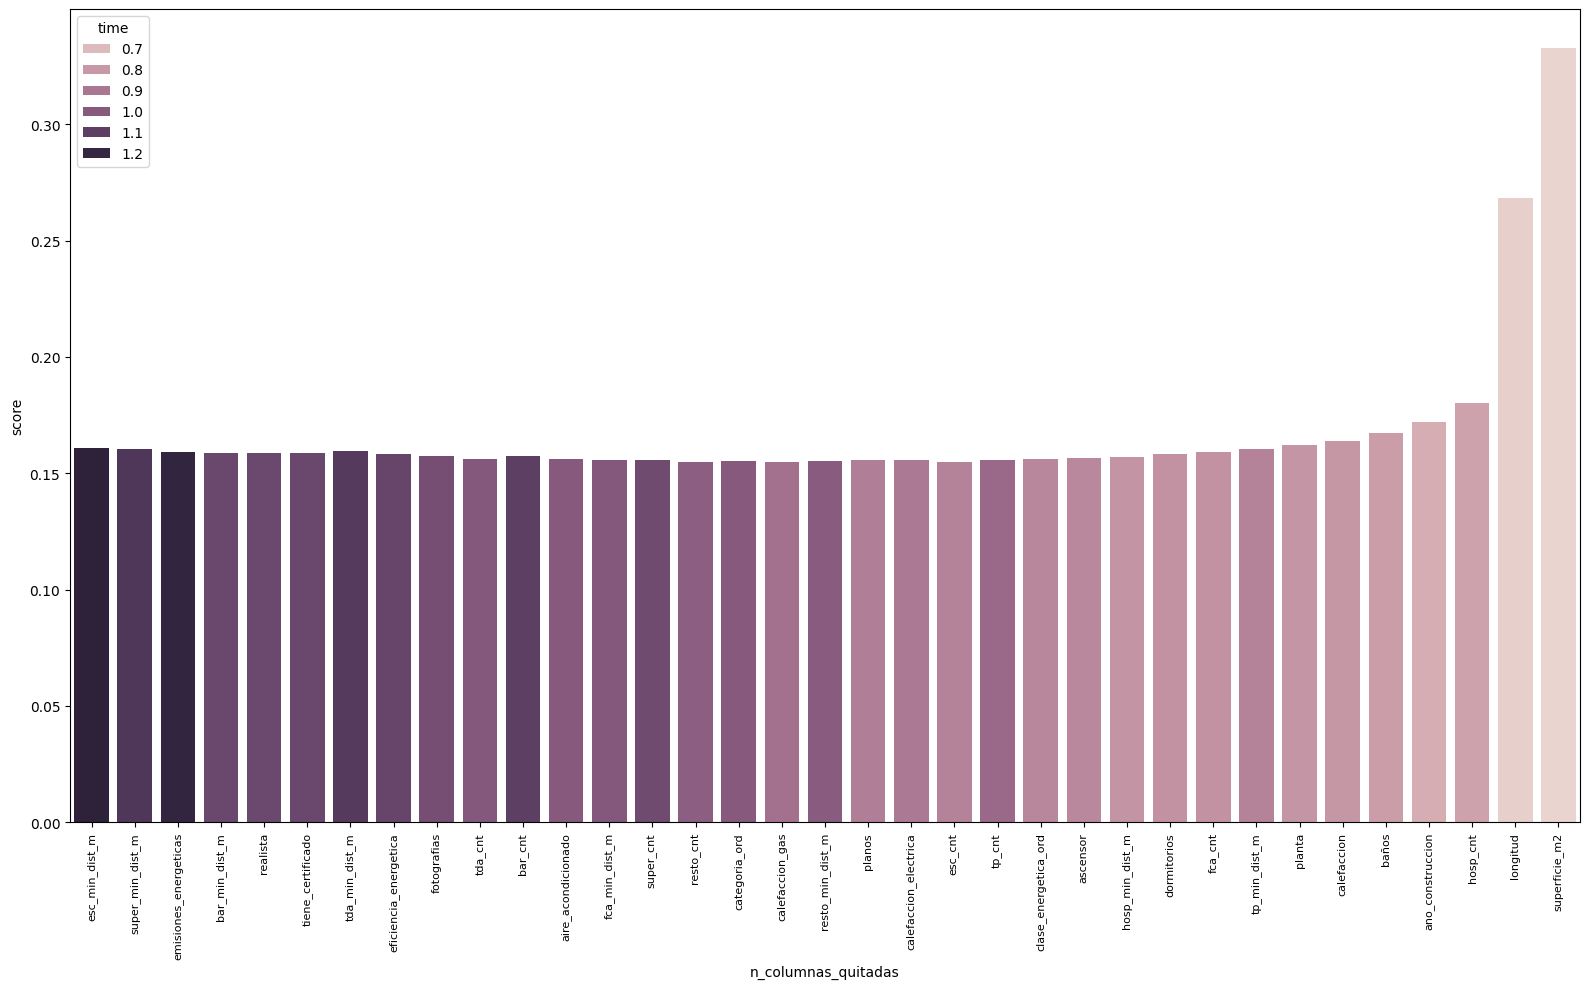

In [83]:
res = resultados_funcion.T.reset_index().reset_index()

res['score'] = res['score'] * -1
res['level_0'] = res['level_0'] + 1

res = res.rename(columns={'level_0': 'n_columnas_quitadas'})

# res['level_0_bin'] = pd.cut(res['level_0'], bins=3)

# sns.barplot(res, x='n_columnas_quitadas', y='score', hue='time')

plt.figure(figsize=(16, 10))
ax = sns.barplot(res, x='n_columnas_quitadas', y='score', hue='time')

ax.set_xticks(range(len(res)))
ax.set_xticklabels(res['index'], rotation=90)
ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()

In [ ]:
res = resultados_funcion.T.reset_index().reset_index()

res['score'] = res['score'] * -1
res['level_0'] = res['level_0'] + 1

res = res.rename(columns={'level_0': 'n_columnas_quitadas'})
res['level_0_bin'] = pd.cut(res['level_0'], bins=3)

plt.figure(figsize=(16, 4))
ax = sns.barplot(data=res, x='n_columnas_quitadas', y='score', hue='time')

ax.set_xticks(range(len(res)))
ax.set_xticklabels(res['n_columnas_quitadas'].astype(int), rotation=90)
ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()

KeyError: 'level_0'

KeyError: 0

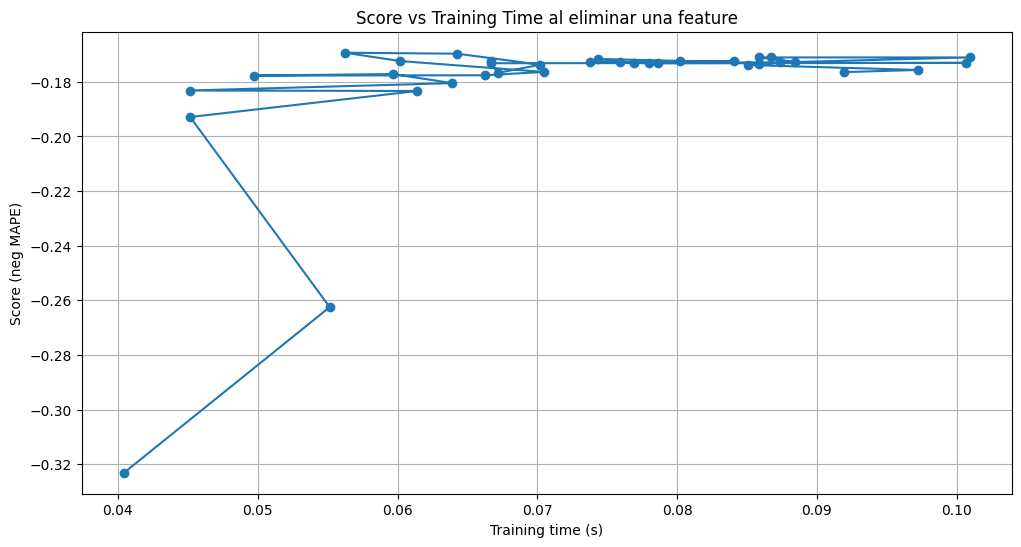

In [103]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos que pegaste
data_dict = {
    'resto_min_dist_m': [-0.176442, 0.091962],
    'tda_min_dist_m': [-0.175658, 0.097252],
    'clase_energetica_ord': [-0.173853, 0.085082],
    'bar_cnt': [-0.173536, 0.085821],
    'resto_cnt': [-0.172666, 0.088403],
    'fotografias': [-0.171068, 0.085876],
    'realista': [-0.171068, 0.086736],
    'tiene_certificado': [-0.171068, 0.100909],
    'calefaccion_electrica': [-0.172898, 0.087332],
    'super_min_dist_m': [-0.172877, 0.073744],
    'aire_acondicionado': [-0.172441, 0.084046],
    'super_cnt': [-0.172358, 0.080208],
    'planos': [-0.171617, 0.074333],
    'esc_cnt': [-0.172667, 0.075941],
    'tda_cnt': [-0.173259, 0.078005],
    'fca_min_dist_m': [-0.173194, 0.078619],
    'tp_min_dist_m': [-0.173060, 0.100677],
    'categoria_ord': [-0.173154, 0.076897],
    'calefaccion_gas': [-0.173196, 0.066683],
    'eficiencia_energetica': [-0.172453, 0.066656],
    'esc_min_dist_m': [-0.176735, 0.067169],
    'bar_min_dist_m': [-0.173731, 0.070225],
    'emisiones_energeticas': [-0.169700, 0.064262],
    'baños': [-0.169344, 0.056251],
    'hosp_cnt': [-0.172386, 0.060162],
    'hosp_min_dist_m': [-0.176375, 0.070457],
    'ascensor': [-0.177600, 0.066276],
    'fca_cnt': [-0.177723, 0.049719],
    'dormitorios': [-0.177148, 0.059661],
    'calefaccion': [-0.180481, 0.063925],
    'planta': [-0.183181, 0.045136],
    'ano_construccion': [-0.183357, 0.061394],
    'tp_cnt': [-0.192888, 0.045169],
    'longitud': [-0.262496, 0.055151],
    'superficie_m2': [-0.323137, 0.040442]
}

# Crear DataFrame
df = pd.DataFrame(data_dict, index=['score', 'time']).T  # Transponemos para tener features en filas

# Plot
plt.figure(figsize=(12,6))
plt.plot(df['time'], df['score'], marker='o', linestyle='-')
plt.xlabel('Training time (s)')
plt.ylabel('Score (neg MAPE)')
plt.title('Score vs Training Time al eliminar una feature')
plt.grid(True)

# Opcional: añadir etiquetas de las features en los puntos
for i, feature in enumerate(df.index):
    plt.text(df['time'][i], df['score'][i], feature, fontsize=8, rotation=45, ha='right', va='bottom')

plt.tight_layout()
plt.show()

Entre las conclusiones podemos decir que el entrenar el modelo como un pipeline completo es muy beneficioso para dejar un modelo listo para producción y totalmente automatizado, con la minima posibilidad de error, pero también conviene destacar que durante las pruebas y para la optimización de hiperparametros castiga mucho el primer paso del pipeline que tiene que desgranar las features y eso le lleva el mayor tiempo de todos los procesos siendo siempre el mismo proceso y resultado, habría que estudiar si podemos hacer este paso antes para que no forme parte del todo del pipeline...

In [66]:
resultados_df.sort_values('score')

,columna,score,time
1,superficie_m2,-0.207358,0.094543
4,longitud,-0.205844,0.089649
3,latitud,-0.202571,0.090766
22,hosp_min_dist_m,-0.185870,0.096266
9,ano_construccion,-0.183744,0.078413
12,fotografias,-0.182931,0.090827
25,tda_cnt,-0.182347,0.108317
17,esc_cnt,-0.182008,0.086196
31,calefaccion_gas,-0.181997,0.102238
26,tda_min_dist_m,-0.181114,0.099954


In [ ]:
RFR_selection = RandomForestRegressor(random_state=42, n_jobs=-1, objective='regression')
pipe_lgb = Pipeline(steps=[('features', pipe_features), ('preprocess', preprocess), ('model', RFR_selection)])

pipe_lgb_log = TransformedTargetRegressor(regressor=pipe_lgb, func=np.log1p, inverse_func=np.expm1)

pipe_lgb_log.fit(X, y)

AttributeError: 'TransformedTargetRegressor' object has no attribute 'feature_importance'